In [1]:
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt
from math import radians, sin, cos, sqrt, atan2


#import dataset
data1 = pd.read_csv('transactions_0.csv', index_col = 0)
data2 = pd.read_parquet('transactions_1.parquet', engine='fastparquet')
data2 = data2.set_index('Unnamed: 0')
data = pd.concat([data1, data2])

#### Question 1: What is the distribution between fraudulent and non-fraudulent transactions?

In [2]:
fraud = data['is_fraud'].map({1.0: 'fraudulent', 0.0: 'non-fraudulent'})
fraud = fraud.value_counts()
print(fraud)

is_fraud
non-fraudulent    663485
fraudulent          3923
Name: count, dtype: int64


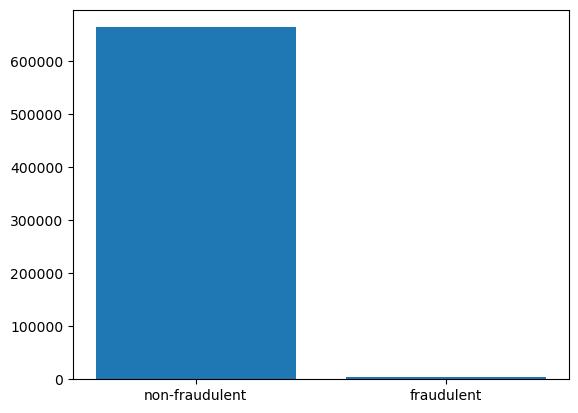

In [3]:
plt.bar(fraud.index, fraud)
plt.show()

The dataset contains 663,485 non-fraudulent transactions and 3923 fraudulent transactions. With the fraudulent cases taking up less than 1% of the dataset, it is said that the dataset is imbalanced. While an imbalanced dataset is not preferred in machine learning tasks, there are several methods to balance out the shortcomings of an imbalanced dataset. Data augmentation can be done to increase the number of minority samples. Synthetic data generation methods, such as SMOTE, can be used to artificially generate synthetic samples for the minority class by interpolating between existing minority samples. Cost-sensitive learning algorithms can give more importance (higher cost) to misclassifications of the minority class to compensate for the lack of training information. Additionally, some machine learning algorithms are more robust to imbalanced datasets. For example, tree-based methods, such as Random Forests, and Gradient Boosting can handle class imbalance better than some linear models. Choosing an appropriate algorithm can help better handle the imbalances dataset. Feature engineering can also be used to help distinguish between classes more effectively.

#### Question 2: Which age groups are more susceptible to fraudulent transactions?

In [4]:
# Convert DOB to datetime
data['dob'] = pd.to_datetime(data['dob'], format = 'mixed')
today = datetime.today()
data['Age'] = data['dob'].apply(lambda x: today.year - x.year - ((today.month, today.day) < (x.month, x.day)))

#creating discretized age groups
bins = [0, 18, 30, 40, 50, 60, 100]
labels = ['0-18', '19-30', '31-40', '41-50', '51-60', '61+']
data['Age Group'] = pd.cut(data['Age'], bins=bins, labels=labels, right=False)

#calculating fraud by age group
fraud_by_age_group = data[data['is_fraud'] == 1]['Age Group'].value_counts().sort_index()
total_by_age_group = data['Age Group'].value_counts().sort_index()
fraud_rate_by_age_group = (fraud_by_age_group / total_by_age_group) * 100


In [5]:
print(fraud_rate_by_age_group)

Age Group
0-18          NaN
19-30    0.675450
31-40    0.431009
41-50    0.349981
51-60    0.487230
61+      0.726148
Name: count, dtype: float64


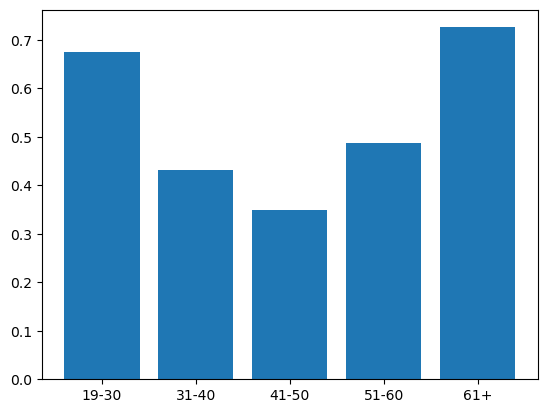

In [6]:
plt.bar(fraud_rate_by_age_group.index, fraud_rate_by_age_group)
plt.show()

The most susceptible age group to fraudulent transactions was found to be the age group of 19 to 30 years old. This was followed by credit card holders of age 61 and over. The least susceptible age group to fraudulent transactions were credit card holders of ages 41 to 50. Instead of the date of birth column, it may be useful to include an age (numerical) or age group (categorical) to the datatset. This allows for any trends between the age and susceptibility to fraudulent charges, in conjunction with other features, to be explored by the machine learning model.

#### Question 4: For each purchase "category," plot the mean and standard "amt" between fraudulent transactions and non-fraudulent transactions)

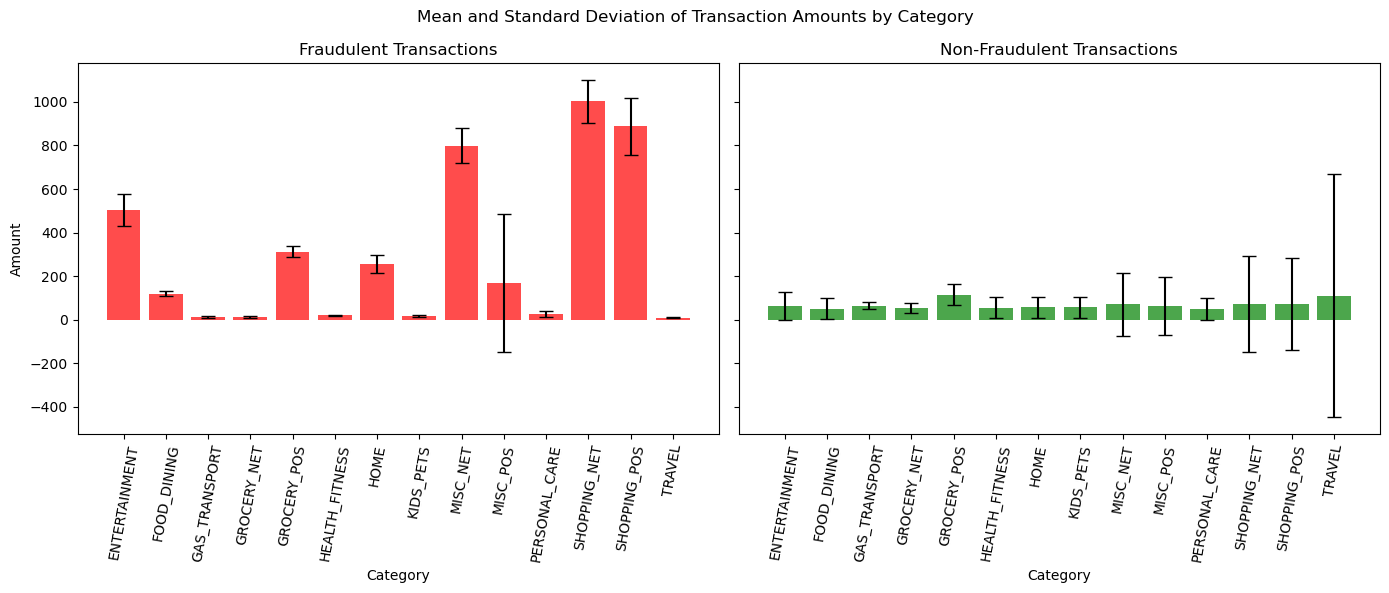

In [7]:
#change all category names to uppercase to standardize
data['category'] = data['category'].str.upper()

# Calculate mean and standard deviation of transaction amounts for each category and fraud status
stats = data.groupby(['category', 'is_fraud'])['amt'].agg(['mean', 'std']).reset_index()

# Separate data for fraudulent and non-fraudulent transactions
fraud_stats = stats[stats['is_fraud'] == 1].set_index('category')
non_fraud_stats = stats[stats['is_fraud'] == 0].set_index('category')

# Plotting
fig, ax = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Fraudulent transactions
ax[0].bar(fraud_stats.index, fraud_stats['mean'], yerr=fraud_stats['std'], capsize=5, color='red', alpha=0.7)
ax[0].set_title('Fraudulent Transactions')
ax[0].set_ylabel('Amount')
ax[0].set_xlabel('Category')
ax[0].tick_params(axis='x', labelrotation = 80)

# Non-fraudulent transactions
ax[1].bar(non_fraud_stats.index, non_fraud_stats['mean'], yerr=non_fraud_stats['std'], capsize=5, color='green', alpha=0.7)
ax[1].set_title('Non-Fraudulent Transactions')
ax[1].set_xlabel('Category')
ax[1].tick_params(axis='x', labelrotation = 80)

plt.suptitle('Mean and Standard Deviation of Transaction Amounts by Category')
plt.tight_layout()
plt.show()

From the bar chart above, it appears that fraudulent charges, in some merchant categories, are much higher than the average spending amoun in fraudulent charges. This suggests that the relationship between the merchant category and the charge amount is a good indicator of whether a charge is fraudulent or not. This is specifically seen in the entertainment, grocery, home, online miscellaneous, online shopping and in-person shopping categories. The fraudulent charges appear to be 5 - 10 times more than the average of charge of the fraudulent charges in the specified categories. This suggests that the category and charge amount can be key features to keep in the dataset.

#### Question 6: Is there a relationship between the distance between customer location (lat/lon) and merchant location (merch_lat/merch_lon) and fraudulent transactions?

Comparing the longitude and latitude of the customer and merchant directly may not be an appropriate feature to evaluate. Instead, it may be more ideal to calculate the distance between the customer's location and the merchant's location. The Haversine formula can be used to calculate the distance. 

In [8]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in kilometers
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat / 2) ** 2 + cos(lat1) * cos(lat2) * sin(dlon / 2) ** 2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))
    distance = R * c
    return distance

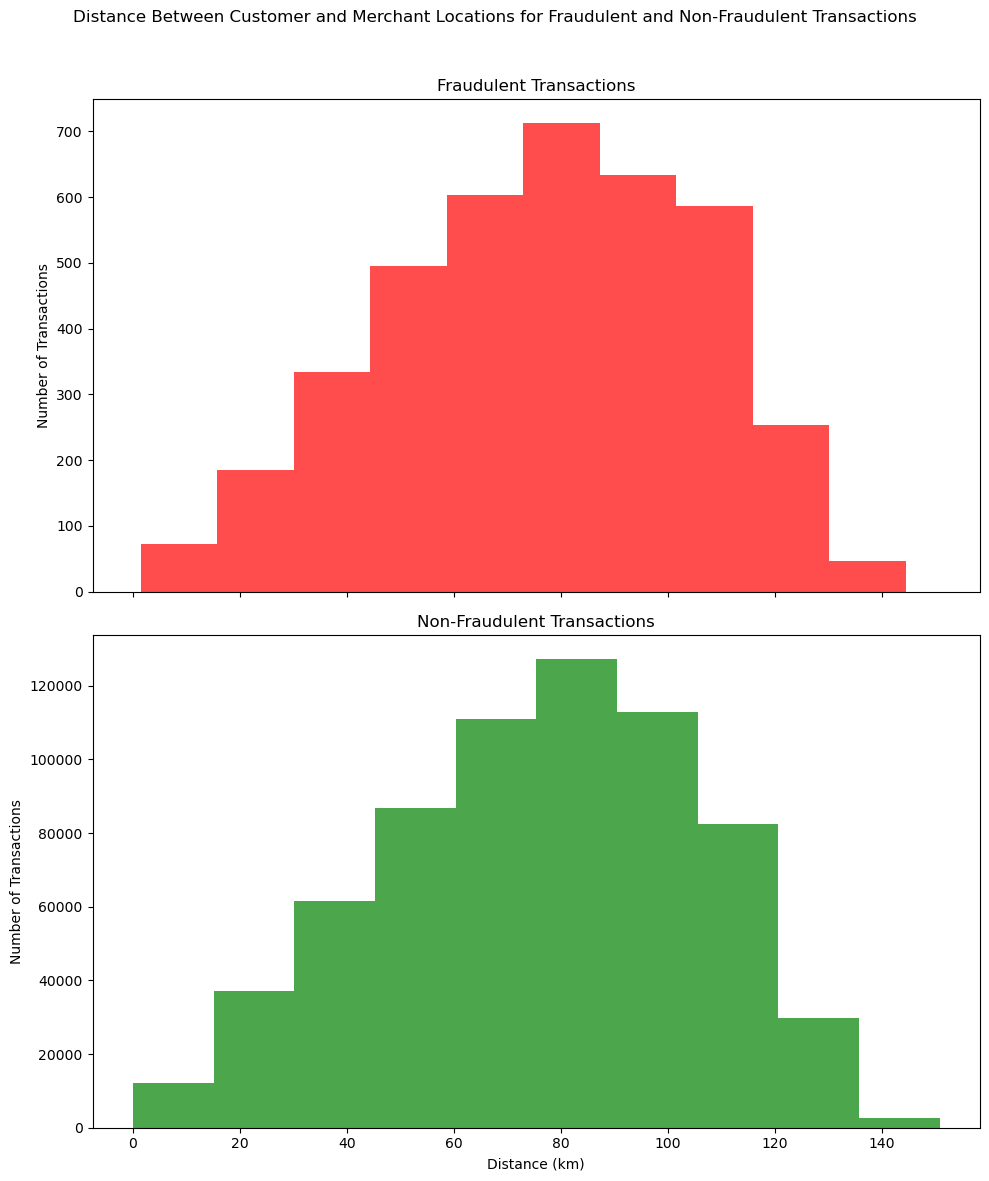

In [9]:
data['distance'] = data.apply(lambda row: haversine(row['lat'], row['long'], row['merch_lat'], row['merch_long']), axis=1)

# Separate data for fraudulent and non-fraudulent transactions
fraud_distances = data[data['is_fraud'] == 1]['distance']
non_fraud_distances = data[data['is_fraud'] == 0]['distance']

# Plotting
fig, axs = plt.subplots(2, 1, figsize=(10, 12), sharex=True)

# Fraudulent transactions histogram
axs[0].hist(fraud_distances, bins=10, alpha=0.7, color='red')
axs[0].set_title('Fraudulent Transactions')
axs[0].set_ylabel('Number of Transactions')

# Non-fraudulent transactions histogram
axs[1].hist(non_fraud_distances, bins=10, alpha=0.7, color='green')
axs[1].set_title('Non-Fraudulent Transactions')
axs[1].set_xlabel('Distance (km)')
axs[1].set_ylabel('Number of Transactions')

plt.suptitle('Distance Between Customer and Merchant Locations for Fraudulent and Non-Fraudulent Transactions')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

From the histograms above, it can be seen that there appears to be no distinct pattern between the fraudulent charges and the distance between the customer and merchant. This also may be due to the presence of online shopping that allows transactions to occur from distances away. Both the fraudulent and non-fraudulent charges appear to follow a normal distribution with the distance. It may be possible to remove the latitude and longitude features of the customer and merchant from the dataset as no notable difference was found. 

#### Question 9: Compared to any other time of the year, how prevalent are fraudulent transactions during the holidays (11-30 to 12-31)? During post-holidays (1-1 to 2-28)? During the summer (05-24 to 09-01)?

In [10]:
# Convert transaction_date to datetime
data['trans_date_trans_time'] = pd.to_datetime(data['trans_date_trans_time'])

print("Earliest Date in Dataset: " + str(data['trans_date_trans_time'].min()))
print("Latest Date in Dataset: " + str(data['trans_date_trans_time'].max()))

Earliest Date in Dataset: 2019-01-01 00:00:18
Latest Date in Dataset: 2019-11-12 22:29:09


The dataset provided only shows the data between January 1, 2019 and November 12, 2019. With the given data, it is not possible to evaluate the fraud rate during the holidays without data ranging from November 30 to December 31. However, the post-holiday period and summer period can be evaluated. 

Fraud Rate during Post-Holidays: 0.98%
Fraud Rate during Summer: 0.41%
Fraud Rate during Rest of the Year: 0.62%


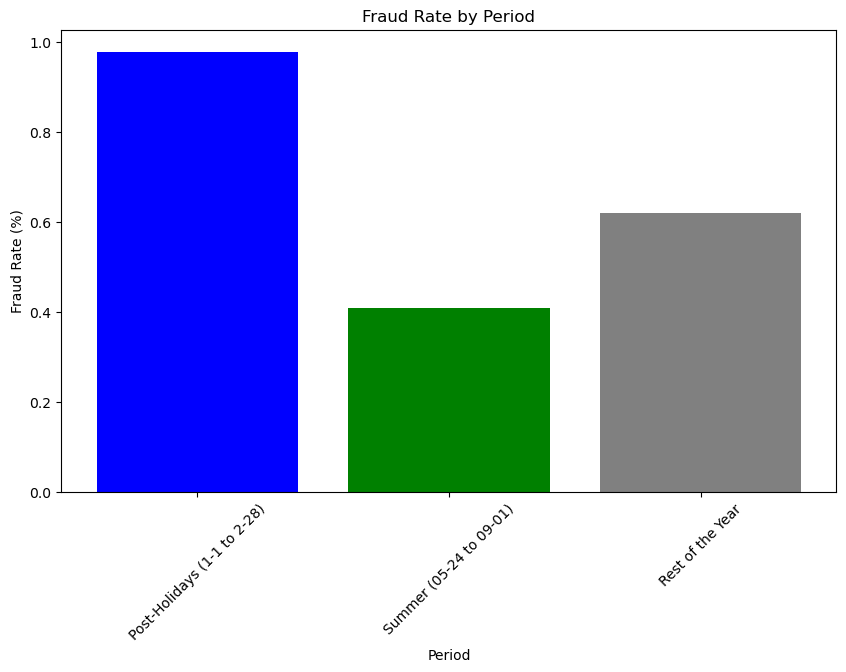

In [11]:
# Define the date ranges
post_holiday_period = (data['trans_date_trans_time'] >= '2019-01-01') & (data['trans_date_trans_time'] <= '2019-02-28')
summer_period = (data['trans_date_trans_time'] >= '2019-05-24') & (data['trans_date_trans_time'] <= '2019-09-01')

# Calculate fraud rate for each period
post_holiday_fraud_rate = data[post_holiday_period]['is_fraud'].mean() * 100
summer_fraud_rate = data[summer_period]['is_fraud'].mean() * 100

# Calculate fraud rate for the rest of the year
rest_of_year = ~(post_holiday_period | summer_period)
rest_of_year_fraud_rate = data[rest_of_year]['is_fraud'].mean() * 100

# Print results
print(f'Fraud Rate during Post-Holidays: {post_holiday_fraud_rate:.2f}%')
print(f'Fraud Rate during Summer: {summer_fraud_rate:.2f}%')
print(f'Fraud Rate during Rest of the Year: {rest_of_year_fraud_rate:.2f}%')

# Visualize the results
periods = ['Post-Holidays (1-1 to 2-28)', 'Summer (05-24 to 09-01)', 'Rest of the Year']
fraud_rates = [post_holiday_fraud_rate, summer_fraud_rate, rest_of_year_fraud_rate]

plt.figure(figsize=(10, 6))
plt.bar(periods, fraud_rates, color=['blue', 'green', 'grey'])
plt.xlabel('Period')
plt.ylabel('Fraud Rate (%)')
plt.title('Fraud Rate by Period')
plt.xticks(rotation=45)
plt.show()

From the bar chart above, it can be seen that the post-holiday period saw a significantly higher 

#### Question 10: Is there a relationship between between "city_pop" and incidence of fraud?

In [12]:
print(data['city_pop'].max())

2906700.0


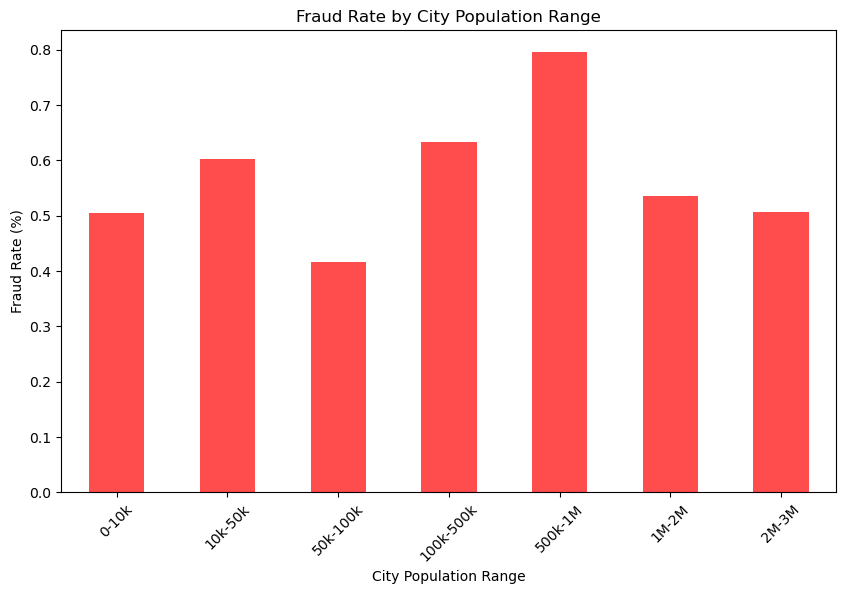

In [13]:
# Create bins for population ranges
bins = [0, 10000, 50000, 100000, 500000, 1000000, 2000000, 3000000]
labels = ['0-10k', '10k-50k', '50k-100k', '100k-500k', '500k-1M', '1M-2M', '2M-3M']
data['pop_bin'] = pd.cut(data['city_pop'], bins=bins, labels=labels, right=False)

# Calculate the number of fraudulent transactions and total transactions per population bin
fraud_counts = data[data['is_fraud'] == 1]['pop_bin'].value_counts().sort_index()
total_counts = data['pop_bin'].value_counts().sort_index()

# Calculate the fraud rate per population bin
fraud_rate = (fraud_counts / total_counts) * 100

# Plotting
plt.figure(figsize=(10, 6))
fraud_rate.plot(kind='bar', color='red', alpha=0.7)
plt.xlabel('City Population Range')
plt.ylabel('Fraud Rate (%)')
plt.title('Fraud Rate by City Population Range')
plt.xticks(rotation=45)
plt.show()

The fraud rate, instead of the fraudulent charge count, is used to compare between the different city population counts. Adjusting for the population size allows for a comparable metric between the city population ranges. It is hypothesized that as the city population increases, the fraud rate would increase - a trend seen in highly populated cities. As seen in the bar chart below, it appears that the fraud rate does vary with the city population size. The highest fraud rate was found in cities with 500k to 1M population, while the lowest fraud rate was found in cities with 50k to 100k population. Surprisingly, it can be seen that cities with 1-3 million population have a significantly lower fraud rate than the 500k to 1M populated cities.